# 504: Peak Warming vs Net-Zero CO2 Year

This notebook analyzes the relationship between peak warming (GSAT|ALL|peak) and the year of net-zero CO2 emissions.

In [46]:
import os
from pathlib import Path

import dotenv
import pandas as pd
import matplotlib.pyplot as plt
import yaml

dotenv.load_dotenv()

OUTPUT_FOLDER = Path(os.environ["OUTPUT_FOLDER"])

# Load IPCC color palette
with open("ipcc_colors.yml") as f:
    IPCC_COLORS = yaml.safe_load(f)

In [47]:
# Load 503 metrics
metrics_df = pd.read_csv(OUTPUT_FOLDER / "503_warming_metrics.csv")
print(f"Loaded {len(metrics_df):,} runs")

# Load cumulative net-negative CO2 and CH4 decline groups from 105
meta_105 = pd.read_csv(OUTPUT_FOLDER / "105_netzero_timings_cumnetnegco2.csv")
meta_105 = meta_105[["model", "scenario", "cumulative_netnegative_co2", "ch4_decline", "ch4_decline_group"]].copy()

# Merge with metrics_df
metrics_df = metrics_df.merge(meta_105, on=["model", "scenario"], how="left")
print(f"Merged metadata for {metrics_df['cumulative_netnegative_co2'].notna().sum():,} runs")

metrics_df.head()

Loaded 409,800 runs
Merged metadata for 409,800 runs


,Unnamed: 0,model,scenario,run_id,peak_year,GSAT|ALL|peak,GSAT|ALL|2100,GSAT|NonCO2_GHG|peak,GSAT|NonCO2_GHG|2100,GSAT|Residual|peak,...,GSAT|ALL|delta,GSAT|CO2_NZCO2|delta,GSAT|CO2_Negative|delta,GSAT|NonCO2_GHG|delta,GSAT|Residual|delta,year_netzero_co2,year_netzero_kyoto_ar6gwp100,cumulative_netnegative_co2,ch4_decline,ch4_decline_group
0,0,AIM/CGE 2.0,SSP1-19,0,2049,1.612907,1.411091,0.092336,-0.093244,-0.041236,...,-0.201816,-0.049494,-0.065621,-0.185580,0.098879,2058.0,2073.0,-135.79,261.96,High CH4 decline
1,1,AIM/CGE 2.0,SSP1-19,1,2093,2.592601,2.577173,0.438947,0.419883,-0.822595,...,-0.015427,0.025233,-0.024810,-0.019064,0.003215,2058.0,2073.0,-135.79,261.96,High CH4 decline
2,2,AIM/CGE 2.0,SSP1-19,2,2049,1.798363,1.577004,0.099817,-0.076595,0.046628,...,-0.221359,-0.027495,-0.069052,-0.176412,0.051601,2058.0,2073.0,-135.79,261.96,High CH4 decline
3,3,AIM/CGE 2.0,SSP1-19,3,2038,1.379944,1.074082,0.098739,-0.197705,0.052872,...,-0.305862,-0.069634,-0.052731,-0.296443,0.112946,2058.0,2073.0,-135.79,261.96,High CH4 decline
4,4,AIM/CGE 2.0,SSP1-19,4,2048,1.645092,1.396311,0.107123,-0.111821,-0.000573,...,-0.248781,-0.058318,-0.062936,-0.218945,0.091418,2058.0,2073.0,-135.79,261.96,High CH4 decline


In [48]:
# Calculate median and percentiles of GSAT|ALL|peak per scenario
scenario_stats = metrics_df.groupby(["model", "scenario"]).agg({
    "GSAT|ALL|peak": [
        lambda x: x.quantile(0.33),
        "median",
        lambda x: x.quantile(0.67)
    ],
    "GSAT|ALL|delta": "median",
    "GSAT|CO2_NZCO2|delta": "median",
    "year_netzero_co2": "first",
    "cumulative_netnegative_co2": "first",
    "ch4_decline": "first",
    "ch4_decline_group": "first"
}).reset_index()

# Flatten column names
scenario_stats.columns = ["model", "scenario", "peak_p33", "peak_median", "peak_p67",
                          "delta_all_median", "delta_co2_nzco2_median", 
                          "year_netzero_co2", "cumulative_netnegative_co2", "ch4_decline", "ch4_decline_group"]

print(f"Scenarios: {len(scenario_stats)}")
print(f"\nCH4 decline group value counts:")
print(scenario_stats["ch4_decline_group"].value_counts(dropna=False))
print(f"\nUnique values: {scenario_stats['ch4_decline_group'].unique()}")

Scenarios: 683

CH4 decline group value counts:
ch4_decline_group
Medium CH4 decline    237
High CH4 decline      234
Low CH4 decline       212
Name: count, dtype: int64

Unique values: ['High CH4 decline' 'Low CH4 decline' 'Medium CH4 decline']


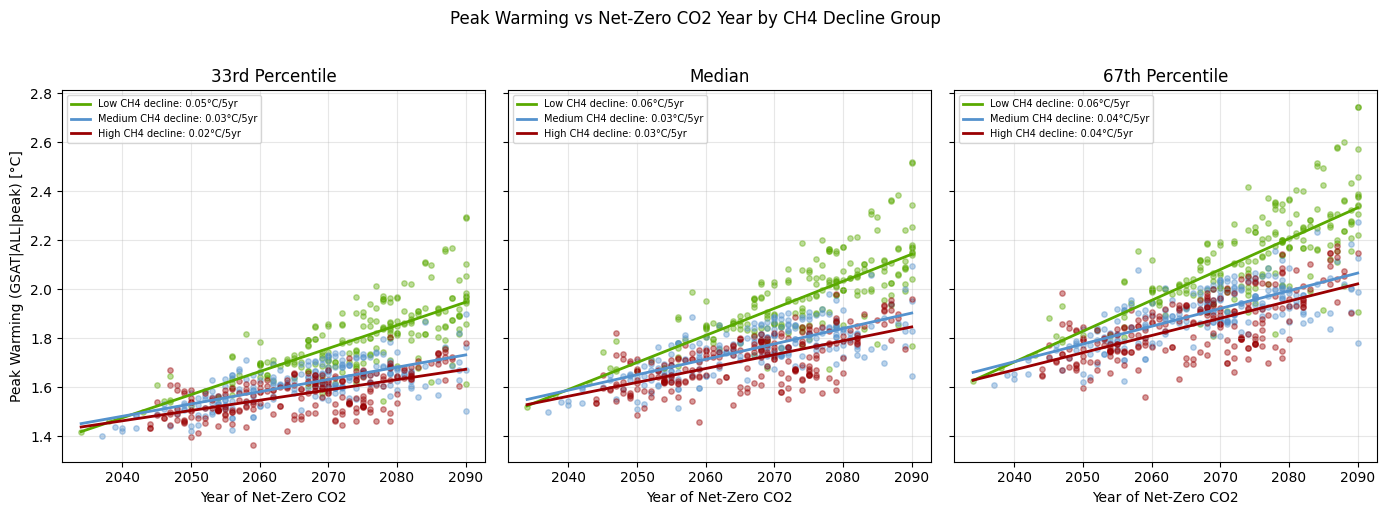

In [49]:
# Scatter plot: Peak warming vs net-zero CO2 year, grouped by CH4 decline
# Three subplots for p33, median, p67
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True, sharex=True)

# Filter for valid data
plot_data = scenario_stats.dropna(subset=["ch4_decline_group", "year_netzero_co2"]).copy()

# Define colors directly as hex strings
GROUP_COLORS = {
    "Low CH4 decline": "#59a900",      # Bright Green
    "Medium CH4 decline": "#5492cd",   # IPCC Blue
    "High CH4 decline": "#990002",     # Warm Red
}

percentiles = [("peak_p33", "33rd Percentile"), ("peak_median", "Median"), ("peak_p67", "67th Percentile")]

x_fit = np.linspace(plot_data["year_netzero_co2"].min(), plot_data["year_netzero_co2"].max(), 100)

for ax, (col, title) in zip(axes, percentiles):
    for group in ["Low CH4 decline", "Medium CH4 decline", "High CH4 decline"]:
        subset = plot_data[plot_data["ch4_decline_group"] == group]
        x = subset["year_netzero_co2"].values
        y = subset[col].values
        hex_color = GROUP_COLORS[group]
        
        # Scatter points
        ax.scatter(x, y, facecolors=hex_color, edgecolors=hex_color, alpha=0.4, s=15)
        
        # Linear regression
        valid = ~np.isnan(y)
        if valid.sum() > 1:
            slope, intercept = np.polyfit(x[valid], y[valid], 1)
            ax.plot(x_fit, slope * x_fit + intercept, 
                    color=hex_color, linewidth=2,
                    label=f"{group}: {slope*5:.2f}°C/5yr")
    
    ax.set_xlabel("Year of Net-Zero CO2")
    ax.set_title(title)
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Peak Warming (GSAT|ALL|peak) [°C]")
fig.suptitle("Peak Warming vs Net-Zero CO2 Year by CH4 Decline Group", fontsize=12, y=1.02)
plt.tight_layout()

In [50]:
group_data["ch4_decline_group"].unique()

array(['High CH4 decline'], dtype=object)

## Cumulative Net-Negative CO2 vs Temperature Change

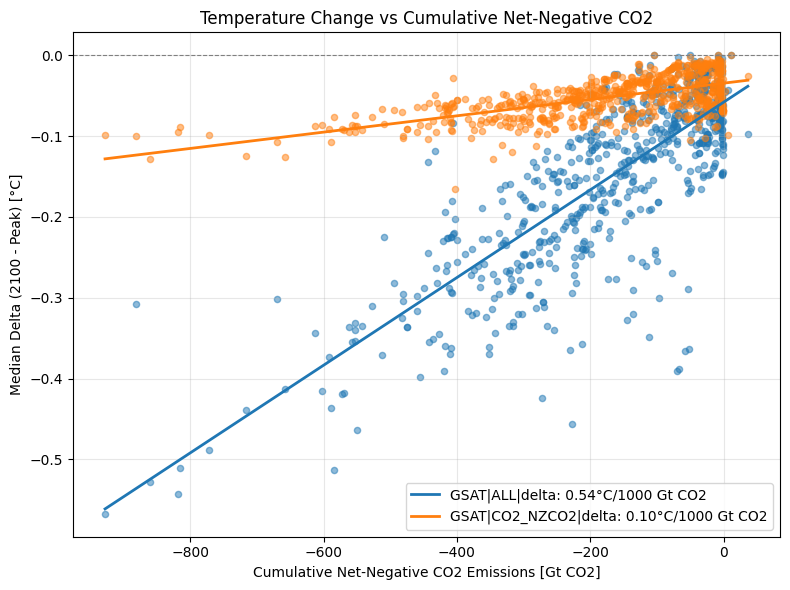

In [51]:
# Scatter plot: Cumulative net-negative CO2 vs median deltas
fig, ax = plt.subplots(figsize=(8, 6))

x = scenario_stats["cumulative_netnegative_co2"]
mask = ~np.isnan(x)
x_fit = np.array([x.min(), x.max()])

# Plot both delta variables
deltas = [
    ("delta_all_median", "GSAT|ALL|delta", IPCC_COLORS[0]),        # IPCC Blue
    ("delta_co2_nzco2_median", "GSAT|CO2_NZCO2|delta", IPCC_COLORS[6]),  # Warm Mustard
]

for col, label, color in deltas:
    y = scenario_stats[col]
    
    ax.scatter(x, y, color=color, alpha=0.5, s=20)
    
    # Linear fit
    m = mask & ~np.isnan(y)
    slope, intercept = np.polyfit(x[m], y[m], 1)
    slope_per_1000 = slope * 1000  # Convert to °C per 1000 Gt CO2
    ax.plot(x_fit, slope * x_fit + intercept, color=color, linewidth=2,
            label=f"{label}: {slope_per_1000:.2f}°C/1000 Gt CO2")

ax.set_xlabel("Cumulative Net-Negative CO2 Emissions [Gt CO2]")
ax.set_ylabel("Median Delta (2100 - Peak) [°C]")
ax.set_title("Temperature Change vs Cumulative Net-Negative CO2")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()